In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron

In [ ]:
# ------------------ From Scratch ------------------
class PerceptronScratch:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        y_ = np.where(y <= 0, -1, 1)   # convert to ±1

        for _ in range(self.n_iters):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_out = np.dot(x_i, self.weights) + self.bias
                y_pred = np.sign(linear_out)
                if y_pred != y_[idx]:
                    update = self.lr * y_[idx]
                    self.weights += update * x_i
                    self.bias += update
                    errors += 1
            if errors == 0:
                break
        return self

    def predict(self, X):
        linear_out = np.dot(X, self.weights) + self.bias
        y_pred = np.sign(linear_out)
        return np.where(y_pred == -1, 0, 1)

In [ ]:
# ------------------ Data ------------------
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# ------------------ Scratch model ------------------
scratch_model = PerceptronScratch(learning_rate=0.1, n_iters=100)
scratch_model.fit(X_train, y_train)
y_pred_scratch = scratch_model.predict(X_test)
print(f"Scratch accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}")

Scratch accuracy: 1.0000


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron

# ------------------ scikit-learn model (fixed) ------------------
sk_model = Perceptron(eta0=0.1, max_iter=100, random_state=42)
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)
print(f"scikit-learn accuracy: {accuracy_score(y_test, y_pred_sk):.4f}")

scikit-learn accuracy: 1.0000


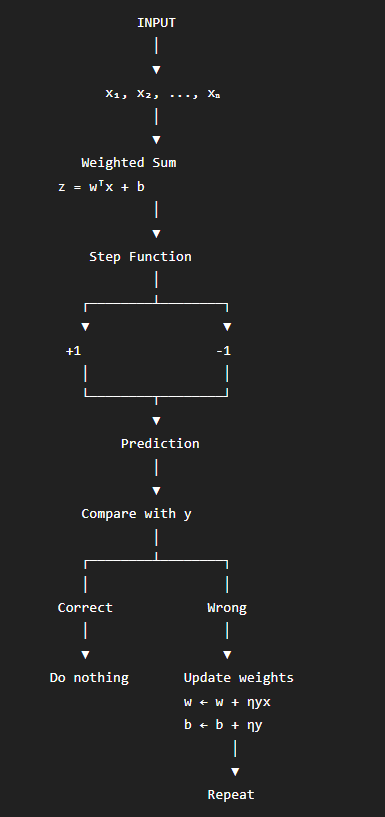

# For the Liner dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron

# ---------- Perceptron from scratch ----------
class PerceptronScratch:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        y_ = np.where(y <= 0, -1, 1)   # convert to ±1 for update rule

        for _ in range(self.n_iters):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_out = np.dot(x_i, self.weights) + self.bias
                y_pred = np.sign(linear_out)
                if y_pred != y_[idx]:
                    update = self.lr * y_[idx]
                    self.weights += update * x_i
                    self.bias += update
                    errors += 1
            if errors == 0:
                break
        return self

    def predict(self, X):
        linear_out = np.dot(X, self.weights) + self.bias
        y_pred = np.sign(linear_out)
        return np.where(y_pred == -1, 0, 1)

# Helper: plot data and decision boundary for scratch model
def plot_decision_boundary(X, y, model, title):
    plt.figure(figsize=(8, 6))
    # Scatter data
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.7)

    # Plot decision boundary (if model has weights)
    if model.weights is not None:
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr', levels=[-0.1, 0.5, 1.1])
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

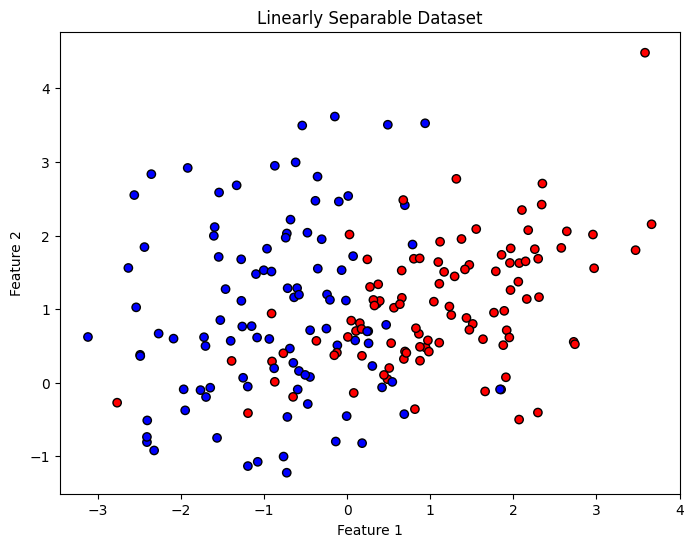

In [ ]:
# Linear dataset (linearly separable)
X_lin, y_lin = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, n_clusters_per_class=1,
                                   random_state=42)
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42)

# Plot the linear data
plt.figure(figsize=(8, 6))
plt.scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, cmap='bwr', edgecolors='k')
plt.title("Linearly Separable Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Linear dataset - Scratch Perceptron accuracy: 0.7750
Linear dataset - scikit-learn Perceptron accuracy: 0.8500


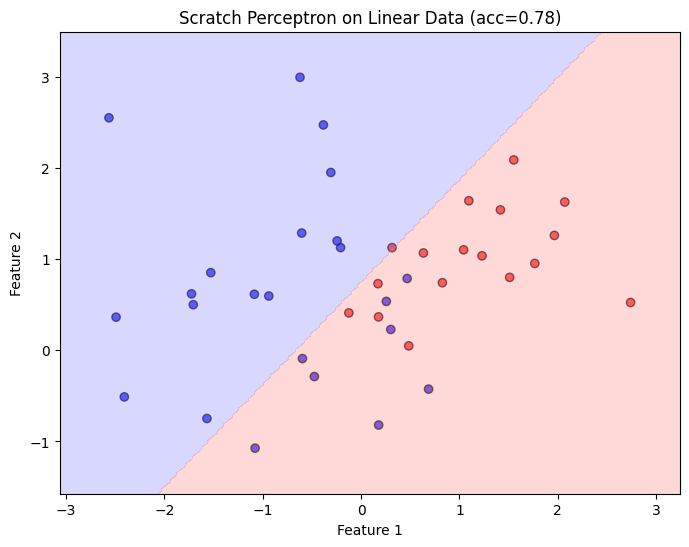

In [ ]:
# ---------- Scratch Perceptron ----------
scratch_lin = PerceptronScratch(learning_rate=0.1, n_iters=100)
scratch_lin.fit(X_lin_train, y_lin_train)
y_pred_scratch_lin = scratch_lin.predict(X_lin_test)
acc_scratch_lin = accuracy_score(y_lin_test, y_pred_scratch_lin)

# ---------- scikit-learn Perceptron ----------
sk_lin = Perceptron(eta0=0.1, max_iter=100, random_state=42)
sk_lin.fit(X_lin_train, y_lin_train)
y_pred_sk_lin = sk_lin.predict(X_lin_test)
acc_sk_lin = accuracy_score(y_lin_test, y_pred_sk_lin)

print(f"Linear dataset - Scratch Perceptron accuracy: {acc_scratch_lin:.4f}")
print(f"Linear dataset - scikit-learn Perceptron accuracy: {acc_sk_lin:.4f}")

# Plot decision boundary from scratch model
plot_decision_boundary(X_lin_test, y_lin_test, scratch_lin,
                       f"Scratch Perceptron on Linear Data (acc={acc_scratch_lin:.2f})")

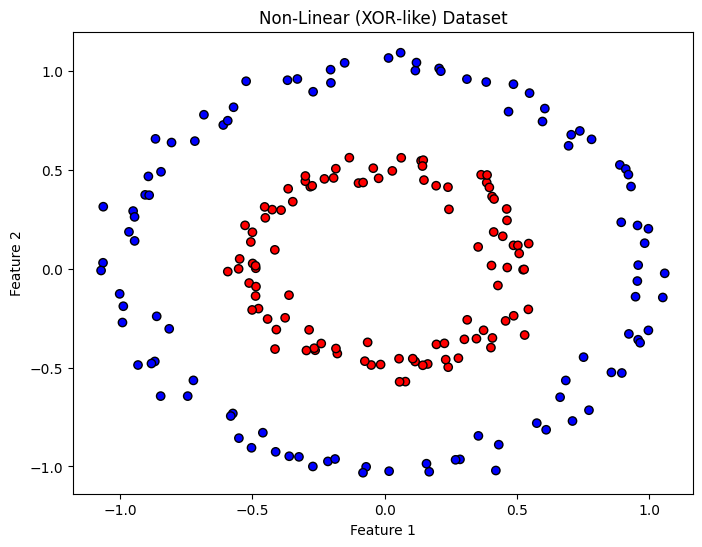

In [ ]:
# Non-linear dataset (two interleaving circles)
X_nl, y_nl = make_circles(n_samples=200, factor=0.5, noise=0.05, random_state=42)
X_nl_train, X_nl_test, y_nl_train, y_nl_test = train_test_split(
    X_nl, y_nl, test_size=0.2, random_state=42)

# Plot the non-linear data
plt.figure(figsize=(8, 6))
plt.scatter(X_nl[:, 0], X_nl[:, 1], c=y_nl, cmap='bwr', edgecolors='k')
plt.title("Non‑Linear (XOR‑like) Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Non‑linear dataset - Scratch Perceptron accuracy: 0.4500
Non‑linear dataset - scikit-learn Perceptron accuracy: 0.4500


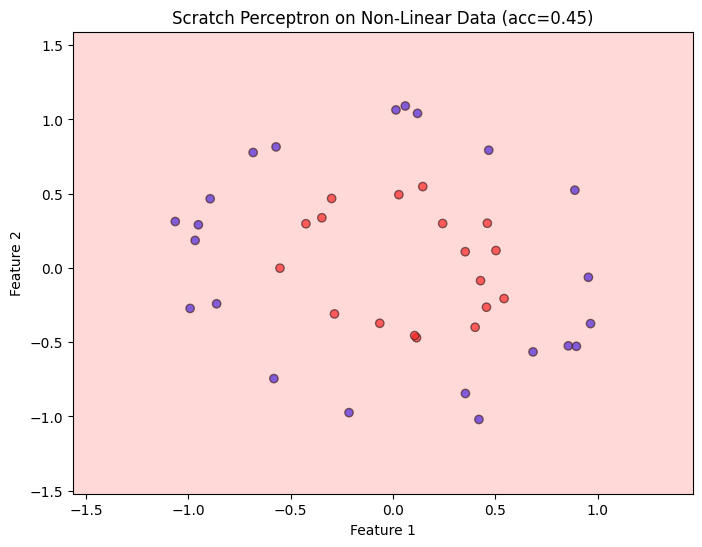

In [ ]:
# ---------- Scratch Perceptron ----------
scratch_nl = PerceptronScratch(learning_rate=0.1, n_iters=200)  # more iterations just in case
scratch_nl.fit(X_nl_train, y_nl_train)
y_pred_scratch_nl = scratch_nl.predict(X_nl_test)
acc_scratch_nl = accuracy_score(y_nl_test, y_pred_scratch_nl)

# ---------- scikit-learn Perceptron ----------
sk_nl = Perceptron(eta0=0.1, max_iter=200, random_state=42)
sk_nl.fit(X_nl_train, y_nl_train)
y_pred_sk_nl = sk_nl.predict(X_nl_test)
acc_sk_nl = accuracy_score(y_nl_test, y_pred_sk_nl)

print(f"Non‑linear dataset - Scratch Perceptron accuracy: {acc_scratch_nl:.4f}")
print(f"Non‑linear dataset - scikit-learn Perceptron accuracy: {acc_sk_nl:.4f}")

# Plot decision boundary from scratch model (it will be a straight line)
plot_decision_boundary(X_nl_test, y_nl_test, scratch_nl,
                       f"Scratch Perceptron on Non‑Linear Data (acc={acc_scratch_nl:.2f})")